In [33]:
import os
import multiprocessing as mp

# use all available cores
print('Using {} cores'.format(mp.cpu_count()))
xla_flag = '--xla_force_host_platform_device_count=' + str(mp.cpu_count())
os.environ['XLA_FLAGS']='--xla_force_host_platform_device_count=256'

import jax
import jax.numpy as jnp
from jax.random import normal, PRNGKey
from jax import lax
import numpy as np
import equinox as eqx
import diffrax as dfrx
import matplotlib.pyplot as plt 
import matplotlib as mpl
import sys
import time

from joblib import Parallel, delayed

# add the odes directory to the path
sys.path.insert(0, '../odes')
import ampk_MA_double_mech_diffrax as model

# cpu mode
jax.config.update('jax_platform_name', 'cpu')
# tell Jax to use 64 bit precision
jax.config.update("jax_enable_x64", True)
%matplotlib inline
# plt.style.use('~/.matplotlib/custom.mplstyle')
# mpl.rcParams['figure.autolayout'] = True

Using 24 cores


In [34]:
len(jax.devices())

256

In [35]:
# metabolism_params
metab_parms_basal = {
    'kGly': 1300.0,
    'kHydro':1.4e-3,
    'kForAK':40.44,
    'kRevAK':1.1e-3,
    'VmaxOxPhos':0.5,
    'Kadp': 5.8e-2,
    'n': 2.568,}

metab_parms_stress = {
    'kGly': 4.5,
    'kHydro':1.4e-3,
    'kForAK':40.44,
    'kRevAK':1.1e-3,
    'VmaxOxPhos':0.5,
    'Kadp': 5.8e-2,
    'n': 2.568,}

# rhs 
rhs = model.ampk_MA_double_mech(**metab_parms_basal)
rhs_stress = model.ampk_MA_double_mech(**metab_parms_stress)
rhs = dfrx.ODETerm(rhs)
rhs_stress = dfrx.ODETerm(rhs_stress)
# model parameters
nominal_vals_MA = [
    2.5e-3, # KdAMP
    1.5e-3, # KdADP
    1.7e-3, # KdATP
    90.467, # kOnCaMKK = (koff+kphos/Km)
    0.357, # kPhosCaMKK
    0.742, # kOnLKB1
    3.92e-2, # kPhosLKB1
    16.56, # kOnPP
    1.1e-1, # kDephosPP
    1569.59, # kOnAMPK
    6.33, # kPhosAMPK
    16.56, # kOnPP1
    1.1e-1, # kDephosPP1
    1e-3, # AMPKAR
]

def compute_MA_params(params):
    return (1.0, # kOnAMP
            params[0], # kOffAMP
            1.0 , # kOnADP
            params[1], # kOffADP
            1.0, # kOnATP
            params[2], # kOffATP
            params[3], # kOnCaMKK
            1.0, # kOffCaMKK
            params[4], # kPhosCaMKK
            params[5], # kOnLKB1
            1.0, # kOffLKB1
            params[6], # kPhosLKB1
            params[7], # kOnPP
            1.0, # kOffPP
            params[8], # kDephosPP
            params[9], # kOnAMPK
            1.0, # kOffAMPK
            params[10], # kPhosAMPK
            params[11], # kOnPP1
            1.0, # kOffPP1
            params[12]) # kDephosPP1

# initial conditions
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'AMP_AMP_AMPK', 'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 'ADP_ADP_AMPK', 'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 'AMP_AMP_pAMPK', 'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ADP_pAMPK', 'ADP_ATP_pAMPK', 'ATP_ATP_pAMPK', 'CaMKK', 'CaMKK_AMPK', 'CaMKK_AMP_AMPK', 'CaMKK_ADP_AMPK', 'CaMKK_ATP_AMPK', 'CaMKK_AMP_AMP_AMPK', 'CaMKK_AMP_ADP_AMPK', 'CaMKK_AMP_ATP_AMPK', 'CaMKK_ADP_ADP_AMPK', 'CaMKK_ADP_ATP_AMPK', 'CaMKK_ATP_ATP_AMPK', 'LKB1', 'LKB1_AMP_AMPK', 'LKB1_ADP_AMPK', 'LKB1_AMP_AMP_AMPK', 'LKB1_AMP_ADP_AMPK', 'LKB1_ADP_ADP_AMPK', 'PP', 'PP_pAMPK', 'PP_ATP_pAMPK', 'PP_AMP_ATP_pAMPK', 'PP_ADP_ATP_pAMPK', 'PP_ATP_ATP_pAMPK', 'AMPKAR', 'pAMPKAR', 'AMPKAR_AMP_pAMPK', 'AMPKAR_AMP_AMP_pAMPK', 'AMPKAR_AMP_ADP_pAMPK', 'PP1', 'PP1_pAMPKAR']

to_set = ['AMP', 'ADP', 'ATP', 'AMPK', 'CaMKK', 'LKB1', 'PP', 'AMPKAR', 'PP1']
idxs = [state_names.index(item) for item in to_set]

print(idxs)

y0 = np.zeros((53,))
y0[idxs[0]] = 2e-5   # 'AMP' mM
y0[idxs[1]] = 1.3e-1 # 'ADP mM
y0[idxs[2]] = 8.2   # 'ATP mM
y0[idxs[3]] = 0.6   # 'AMPK mM
y0[idxs[4]] = 1.0   # 'CaMKK_AMPK mM
y0[idxs[5]] = 1.0   # 'CaMKK_AMPK mM
y0[idxs[6]] = 1.0   # 'CaMKK_AMPK mM
y0[idxs[7]] = 0.1   # 'AMPKAR mM
y0[idxs[8]] = 1.0   # 'CaMKK_AMPK mM

y0 = np.array(y0)

[0, 1, 2, 3, 23, 34, 40, 46, 51]


In [36]:
## Solver overhead
solver=dfrx.Kvaerno5()
stepsize_controller = dfrx.PIDController(rtol=1e-8, atol=1e-8)
t0 = 0.0
t1 = 1000.0 # 1000 seconds
times = np.arange(t0, t1, 0.5)
dt0 = 1e-3 # initial time step
saveat=dfrx.SaveAt(ts=times)

# solve
sol_dfrx = dfrx.diffeqsolve(
    rhs, 
    solver, 
    t0, t1, dt0, 
    y0, 
    saveat=saveat, stepsize_controller=stepsize_controller,
    args=compute_MA_params(nominal_vals_MA))

print(sol_dfrx)

Solution(
  t0=f64[],
  t1=f64[],
  ts=f64[2000],
  ys=f64[2000,53],
  interpolation=None,
  stats={
    'max_steps':
    i64[],
    'num_accepted_steps':
    i64[],
    'num_rejected_steps':
    i64[],
    'num_steps':
    i64[]
  },
  result=i64[],
  solver_state=None,
  controller_state=None,
  made_jump=None
)


In [40]:
pvals = compute_MA_params(nominal_vals_MA)
pvals = tuple([np.nan for p in pvals])
sol_dfrx = dfrx.diffeqsolve(
    rhs, 
    solver, 
    t0, t1, dt0, 
    y0, 
    saveat=saveat, stepsize_controller=stepsize_controller,
    args=pvals)


XlaRuntimeError: INTERNAL: Generated function failed: CpuCallback error: RuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.

At:
  /home/nlinden/mambaforge/envs/pymc5_env/lib/python3.11/site-packages/equinox/internal/_errors.py(18): raises
  /home/nlinden/mambaforge/envs/pymc5_env/lib/python3.11/site-packages/jax/_src/callback.py(144): _flat_callback
  /home/nlinden/mambaforge/envs/pymc5_env/lib/python3.11/site-packages/jax/_src/callback.py(44): pure_callback_impl
  /home/nlinden/mambaforge/envs/pymc5_env/lib/python3.11/site-packages/jax/_src/callback.py(107): _callback
  /home/nlinden/mambaforge/envs/pymc5_env/lib/python3.11/site-packages/jax/_src/interpreters/mlir.py(1810): _wrapped_callback
  /home/nlinden/mambaforge/envs/pymc5_env/lib/python3.11/site-packages/jax/_src/interpreters/pxla.py(1916): __call__
  /home/nlinden/mambaforge/envs/pymc5_env/lib/python3.11/site-packages/jax/_src/profiler.py(314): wrapper
  /home/nlinden/mambaforge/envs/pym

In [42]:
## Now test a solve to steady-state function
# jitable function to run the system to steady-state
@jax.jit
def solve_to_steady_state(params, rhs, y0, thresh=1e-10):
    solver=dfrx.Kvaerno5()
    stepsize_controller = dfrx.PIDController(rtol=1e-8, atol=1e-8)
    t0 = 0.0
    t1 = 1000.0 # 1000 seconds
    times = np.arange(t0, t1, t1/100)
    dt0 = 1e-6 # initial time step
    saveat=dfrx.SaveAt(ts=times)
    times_repeat = np.arange(t0, 100, 100/100)
    saveat_repeat=dfrx.SaveAt(ts=times_repeat)

    # initial solve
    sol = dfrx.diffeqsolve(
        rhs, 
        solver, 
        t0, t1, dt0, 
        y0, 
        saveat=saveat, stepsize_controller=stepsize_controller,
        args=params)

    # solve to steady-state
    # cond_fun checks for steady-state by checking the norm of the RHS
    cond_fun = lambda sol: jnp.linalg.norm(rhs.vector_field(0.0, sol[0].ys[-1,:], params)) > thresh
    # body_fun solves the ODEs for 100 more seconds
    body_fun = lambda sol: (dfrx.diffeqsolve(rhs, solver, t0, 100, dt0, sol[0].ys[-1,:], 
        saveat=saveat_repeat, stepsize_controller=stepsize_controller, args=params),
        sol[1]+100)
    
    # while loop until steady state condition is reached
    sol_final = lax.while_loop(cond_fun, body_fun, (sol, 1000))
    
    return sol_final # returns the final state

In [20]:
# run to steady-state
sol_ss = solve_to_steady_state(compute_MA_params(nominal_vals_MA), rhs, y0, 1e-12)
t0 = 0.0
# new simulation for the time it too to reach steady-state
t1 = sol_ss[1] # 1000 seconds
times = np.arange(t0, t1, 1)
dt0 = 1e-3 # initial time step
saveat=dfrx.SaveAt(ts=times)

# solve
sol_dfrx = dfrx.diffeqsolve(
    rhs, 
    solver, 
    t0, t1, dt0, 
    y0, 
    saveat=saveat, stepsize_controller=stepsize_controller,
    args=compute_MA_params(nominal_vals_MA))

# apply stimulus and run again
sol_stim = solve_to_steady_state(compute_MA_params(nominal_vals_MA), rhs_stress, sol_ss[0].ys[-1,:], 1e-10)

t1 = sol_stim[1] # 1000 seconds
times = np.arange(t0, t1, 1)
dt0 = 1e-3 # initial time step
saveat=dfrx.SaveAt(ts=times)

sol_stim = dfrx.diffeqsolve(
    rhs_stress, 
    solver, 
    t0, t1, dt0, 
    sol_ss[0].ys[-1,:],
    saveat=saveat, stepsize_controller=stepsize_controller,
    args=compute_MA_params(nominal_vals_MA))

Text(0.5, 1.0, 'Steady-state stimulus test (nominal parameters)')

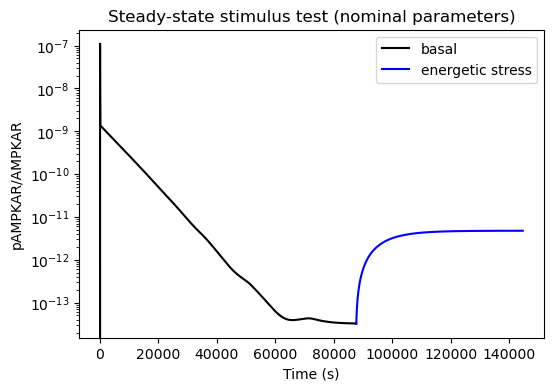

In [21]:
# make a plot
fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(sol_dfrx.ts, sol_dfrx.ys[:,47]/sol_dfrx.ys[:,46], 'k', label='basal')
ax.plot(sol_dfrx.ts[-1]+sol_stim.ts, sol_stim.ys[:,47]/sol_stim.ys[:,46], 'b', label='energetic stress')
ax.set_yscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('pAMPKAR/AMPKAR')
ax.legend()
ax.set_title('Steady-state stimulus test (nominal parameters)')

In [88]:
@jax.jit
def single_model_eval(params, rhs_basal, rhs_stress, y0, ampkar_idx=46, pampkar_idx=47):
    # update y0 for AMPKAR
    y0 = y0.at[ampkar_idx].set(params[-1])

    # find basal steady-state
    sol_basal = solve_to_steady_state(params, rhs_basal, y0, 1e-12)

    # apply stimulus and run again
    sol_stress = solve_to_steady_state(params, rhs_stress, sol_basal[0].ys[-1,:], 1e-10)

    # compute the ratio of pAMPKAR/AMPKAR at the end of the stress simulation
    basal_ratio = sol_basal[0].ys[-1,pampkar_idx]/sol_basal[0].ys[-1,ampkar_idx]
    stress_ratio = sol_stress[0].ys[-1,pampkar_idx]/sol_stress[0].ys[-1,ampkar_idx]
    norm_change = (stress_ratio - basal_ratio) / basal_ratio
    
    return jnp.array([norm_change, basal_ratio, stress_ratio])

@jax.jit
def single_model_eval_nansafe(params, rhs_basal, rhs_stress, y0):
    pred = jnp.sum(jnp.isnan(params))
    false_fun = lambda params: single_model_eval(params, rhs_basal, rhs_stress, y0)
    true_fun = lambda params: jnp.array([jnp.nan, jnp.nan, jnp.nan])
    return lax.cond(pred, true_fun, false_fun, params)

In [90]:
qoi = single_model_eval(compute_MA_params(nominal_vals_MA), rhs, rhs_stress, y0)

In [89]:
qoi = single_model_eval_nansafe(np.array(compute_MA_params(nominal_vals_MA)), rhs, rhs_stress, y0)
print(qoi)

[1.47137553e+02 3.20965762e-14 4.75470825e-12]


In [84]:
%timeit single_model_eval(compute_MA_params(nominal_vals_MA), rhs, rhs_stress, y0)

1.02 s ± 1.26 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
#with Parallel(n_jobs=8) as parallel:
#    p_list = [compute_MA_params(nominal_vals_MA) for i in range(16)]
#    sol_list = parallel(delayed(single_model_eval)(p, rhs, rhs_stress, y0) for p in p_list)

In [92]:
# qoi_fn = lambda params: single_model_eval(params, rhs, rhs_stress, y0)
qoi_fn_pmap = jax.pmap(single_model_eval_nansafe, in_axes=(0, None, None, None))

In [93]:
tmp = qoi_fn_pmap(jnp.array([compute_MA_params(nominal_vals_MA) for i in range(2)]), rhs, rhs_stress, y0)

In [94]:
params = jnp.array([compute_MA_params(nominal_vals_MA) for i in range(256)])
key = jax.random.PRNGKey(1024)
params = params + 1e-5*normal(key, shape=params.shape)

tnow = time.time()
sols = []
for i in range(1):
    sol = qoi_fn_pmap(params, rhs, rhs_stress, y0)
    sols.append(sol)
tend = time.time()
print('It took {} seconds to run 1024 simulations'.format(tend-tnow))

It took 32.55074858665466 seconds to run 1024 simulations


In [ ]:
params = jnp.array([compute_MA_params(nominal_vals_MA) for i in range(1024)])
key = jax.random.PRNGKey(1024)
params = params + 1e-5*normal(key, shape=params.shape)


tnow = time.time()
sol = qoi_fn_pmap(params, rhs, rhs_stress, y0)
tend = time.time()
print('It took {} seconds to run 1024 simulations'.format(tend-tnow))

In [13]:
qoi

Array([1.47137553e+02, 3.20965762e-14, 4.75470825e-12], dtype=float64)

In [32]:
a = jnp.array([1.0, 2.0, 3.0])

func = lambda x: x+x
fn_pmap = jax.pmap(func, in_axes=(0,))

s = []
key = jax.random.PRNGKey(1024)
inputs = normal(key, shape=(2, 3, 3))
for i in range(inputs.shape[0]):
    sol = fn_pmap(inputs[i,:,:])
    s.append(sol)
print(np.array(s))
p = [func(x) for x in jnp.reshape(inputs, (6,3))]
print(p)

[[[ 2.83622311 -0.62610406  1.30584574]
  [ 0.05389066  3.32245488 -1.08353673]
  [ 1.04100329  1.51483855  0.99182168]]

 [[ 2.17866028  4.18578708 -0.08692813]
  [-0.96852003 -0.01025833  2.31745233]
  [-3.22320561 -3.41035414  0.77163512]]]
[Array([ 2.83622311, -0.62610406,  1.30584574], dtype=float64), Array([ 0.05389066,  3.32245488, -1.08353673], dtype=float64), Array([1.04100329, 1.51483855, 0.99182168], dtype=float64), Array([ 2.17866028,  4.18578708, -0.08692813], dtype=float64), Array([-0.96852003, -0.01025833,  2.31745233], dtype=float64), Array([-3.22320561, -3.41035414,  0.77163512], dtype=float64)]


In [26]:
[func(x) for x in np.reshape(np.array(inputs), (6,3))]

[array([ 2.83622311, -0.62610406,  1.30584574]),
 array([ 0.05389066,  3.32245488, -1.08353673]),
 array([1.04100329, 1.51483855, 0.99182168]),
 array([ 2.17866028,  4.18578708, -0.08692813]),
 array([-0.96852003, -0.01025833,  2.31745233]),
 array([-3.22320561, -3.41035414,  0.77163512])]